In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [30]:
df=pd.read_csv("online_shoppers_intention.csv")

In [31]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [32]:
# checking the missing data
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [33]:
duplicate=df.duplicated().sum()
if duplicate >0:
    print(f"found {duplicate} row ({duplicate/len(df)*100:.2f})")
else:
    print("no duplicates")

found 125 row (1.01)


In [34]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

In [35]:
#remove duplcates and keeping first records
df=df.drop_duplicates(keep='first').reset_index(drop=True)

In [36]:
# converting chacter to numerical using label encoder
le=LabelEncoder()

In [37]:
#df=le.fit(df['Month'])

In [42]:
df['Month']=le.fit_transform(df['Month'])

In [70]:
df['VisitorType']=le.fit_transform(df['VisitorType'])
df['Revenue']=le.fit_transform(df['Revenue'])

In [72]:
# splitting independent variable and response variable
x=df.drop('Revenue',axis=1)
y=df['Revenue']

In [73]:
#converting MOnth and visitor typr to numeric
x['Month']=x['Month'].astype(int)
x['VisitorType']=x['VisitorType'].astype(int)

In [ ]:
# splitting the data into train and test
x_train=x.iloc[0:int(len(x)*0.8),:]
x_test=x.iloc[int(len(x)*0.8):,:]
y_train=y.iloc[0:int(len(y)*0.8)]
y_test=y.iloc[int(len(y)*0.8):]

In [194]:
# model training,


In [138]:
def log_model(x_train,x_test,y_train,y_test):
    lm=LogisticRegression(max_iter=100)
    result=lm.fit(x_train,y_train)
    y_pred=result.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision_sc=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1_sc=f1_score(y_test,y_pred)
    
    result1=pd.DataFrame({'Model':'LogisticRegression',
        'Accuracy':accuracy,
        'precision_score':precision_sc,
        'recall_score':recall,
        'f1_score':f1_sc
    },index=[1])
        
        
        
    
    return result1

In [147]:
r1=log_model(x_train,x_test,y_train,y_test)

c:\Users\ADMIN\Documents\Data science learning\pythonenv\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
def d_tree(x_train,x_test,y_train,y_test):
    dt=DecisionTreeClassifier(criterion='gini',max_depth=100,random_state=45)
    result=dt.fit(x_train,y_train)
    y_pred=result.predict(x_test)
    
    accuracy=accuracy_score(y_test,y_pred)
    precision_sc=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1_sc=f1_score(y_test,y_pred)
    
    result2=pd.DataFrame({
        'Model':'DecisionTree',
        'Accuracy':accuracy,
        'precision_score':precision_sc,
        'recall_score':recall,
        'f1_score':f1_sc
    },index=[1]
        
    )
    return result2,y_pred
    

In [146]:
r2=d_tree(x_train,x_test,y_train,y_test)

In [ ]:
def r_forest(x_train,x_test,y_train,y_test):
    rf=RandomForestClassifier(n_estimators=100,random_state=45)
    result=rf.fit(x_train,y_train)
    y_pred_rf=result.predict(x_test)
    
    accuracy=accuracy_score(y_test,y_pred_rf)
    precision_sc=precision_score(y_test,y_pred_rf)
    recall=recall_score(y_test,y_pred_rf)
    f1_sc=f1_score(y_test,y_pred_rf)
    
    result3=pd.DataFrame({
        'Model':'RandomForest',
        'Accuracy':accuracy,
        'precision_score':precision_sc,
        'recall_score':recall,
        'f1_score':f1_sc
    },index=[1])
                                          
    param={
        'n_estimators':[100,200,300],
        'criterion':['gini', 'entropy']
    }
    # hyper parameter tunning
    grid=GridSearchCV(rf,param_grid=param,cv=5,verbose=True)
    grid_result=grid.fit(x_train,y_train)
    best_rf=grid_result.best_params_
    best_score=grid_result.best_score_
                         
    return best_rf,best_score,y_pred_rf

In [263]:
r_forest(x_train,x_test,y_train,y_test)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


({'criterion': 'entropy', 'n_estimators': 300},
 np.float64(0.8988107304441255),
 array([1, 0, 0, ..., 0, 0, 0], shape=(2441,)))

In [257]:
# comparision of models
model_param={
    
    'LogisticRegression':{
        'model':LogisticRegression(solver='liblinear'),
        'param':{'C':[5,10,20]}
    },
    'DecisionTree':{
        'model': DecisionTreeClassifier(),
        'param':{
            'criterion':['gini', 'entropy'],
            'max_depth':[5,10,12]
        }
    },
    'RandomForest':{
        'model': RandomForestClassifier(random_state=40),
        'param':{
            'n_estimators':[10,20,30],
            
        }
    }
}

In [259]:
#best accuracy with gridsearch CV
best_score=[]
for model_name,mp in model_param.items():
    best=GridSearchCV(mp['model'],mp['param'],cv=5,verbose=1)
    best.fit(x_train,y_train)
    best_score.append({
        'Model':model_name,
        'Accuracy':best.best_score_,
        'Parameters':best.best_params_
    })

best_model_df=pd.DataFrame(best_score,columns=['Model','Accuracy','Parameters'])
best_model_df


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits


,Model,Accuracy,Parameters
0,LogisticRegression,0.890208,{'C': 10}
1,DecisionTree,0.887955,"{'criterion': 'gini', 'max_depth': 5}"
2,RandomForest,0.895225,{'n_estimators': 30}


In [265]:
## building Random forest with n_estimator=30
model_with_new_param=RandomForestClassifier(n_estimators=30, random_state=40)
best_model=model_with_new_param.fit(x_train,y_train)
y_pred_rf=best_model.predict(x_test)

In [271]:
print(accuracy_score(y_test,y_pred_rf))


0.8586644817697665


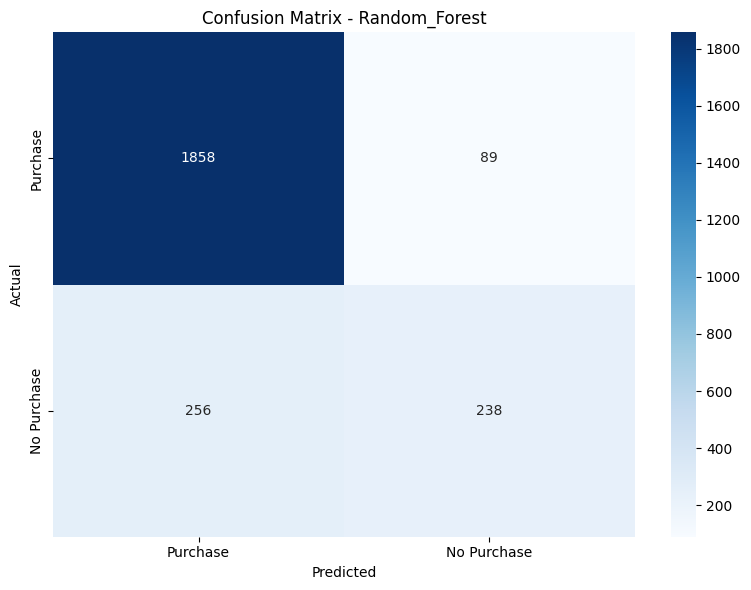

In [278]:
cm=confusion_matrix(y_test,y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d', cmap='Blues', 
            xticklabels=['Purchase','No Purchase'],
            yticklabels=['Purchase','No Purchase'])
plt.title(f'Confusion Matrix - Random_Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [270]:
print(precision_score(y_test,y_pred_rf))
print(recall_score(y_test,y_pred_rf))

0.72782874617737
0.4817813765182186
